# 1. IMPORTING PERTINENT LIBRARIES

In [ ]:
import os
import tqdm
import random

import matplotlib.pyplot as plt
import numpy as np

import cv2

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
%matplotlib inline 

In [7]:
path = "../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection"
yes_path = "../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes"
no_path = "../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no"

../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/yes
Total Images for YES is: 155
../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/no
Total Images for NO is: 98


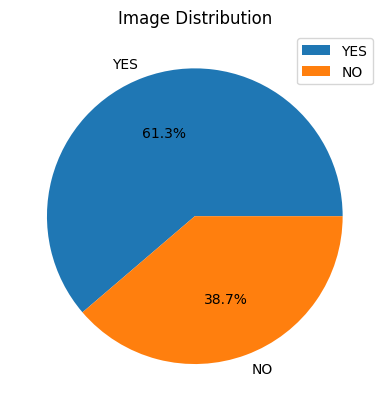

In [8]:
yes_counts = 0
no_counts = 0

# Count images in YES path
for dirpath, dirnames, filenames in os.walk(yes_path):
    print(dirpath)
    print(f"Total Images for YES is: {len(filenames)}")
    yes_counts += len(filenames)

# Count images in NO path
for dirpath, dirnames, filenames in os.walk(no_path):
    print(dirpath)
    print(f"Total Images for NO is: {len(filenames)}")
    no_counts += len(filenames)

# Plot pie chart
plt.pie([yes_counts, no_counts], labels=["YES", "NO"], autopct="%1.1f%%")
plt.title("Image Distribution")
plt.legend()
plt.show()

## 1.1 SETTING CONSTANTS AND PARAMETERS

# GENERATING SAMPLE IMAGES (ORIGINAL)

In [9]:
def load_samples(base_path, num_samples):
    yes_data = []
    no_data = []

    for cls in ["yes", "no"]:
        folder = os.path.join(base_path, cls)
        images = [img for img in os.listdir(folder) if img.lower().endswith((".png", ".jpg", ".jpeg"))]

        sampled = random.sample(images, min(num_samples, len(images)))

        for img_name in sampled:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if cls == "yes":
                yes_data.append(img)
            else:
                no_data.append(img)

    return yes_data, no_data

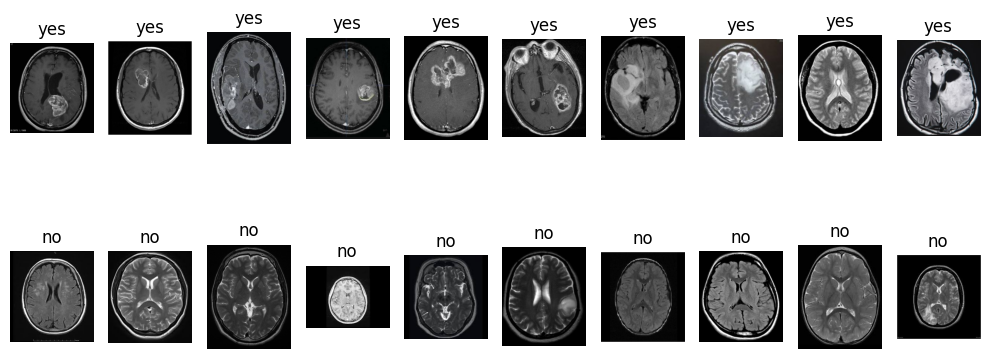

In [11]:
def show_samples(samples):

    plt.figure(figsize=(10, 5))

    for i, (img, label) in enumerate(samples):
        plt.subplot(2, len(samples)//2, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

yes_data, no_data = load_samples(path, 10)
samples = [(img, "yes") for img in yes_data] + \
          [(img, "no") for img in no_data]

show_samples(samples)

#  **PYTORCH DEEP LEARNING**

# TORCH DATA LOADER

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import torch.nn.functional as F

# Torchvision
from torchvision import datasets, transforms, models
from torchvision.models import resnet50, ResNet50_Weights, efficientnet_b4, EfficientNet_B4_Weights

In [13]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

In [14]:
# Root path that contains ONLY "yes" and "no" folders
path = "../input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load dataset once, pointing to the root folder
dataset = datasets.ImageFolder(root=path, transform=transform)

# Check mapping
print(dataset.class_to_idx)

# Create DataLoader
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Example: get one batch
images, labels = next(iter(loader))
print(images.shape)   
print(labels)

{'no': 0, 'yes': 1}


NameError: name 'batch_size' is not defined

# TORCH RANDOM UPSAMPLING

In [ ]:
# Targets
targets = torch.tensor(dataset.targets)

print("Before WRS:", Counter(targets.tolist()))

# Class balancing
class_counts = torch.bincount(targets)
class_weights = 1. / class_counts.float()
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(dataset),
    replacement=True
)

loader = DataLoader(dataset, batch_size=32, sampler=sampler)

sampled_counter = Counter()

for _, batch_labels in loader:
    sampled_counter.update(batch_labels.tolist())

print("After WRS:", sampled_counter)

# One batch check
images, batch_labels = next(iter(loader))
print("One batch distribution:", Counter(batch_labels.tolist()))
print("Batch shape:", images.shape)

In [ ]:
targets = dataset.targets

train_idx, val_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.2,
    stratify=targets,
    random_state=random_seed
)

train_targets = [targets[i] for i in train_idx]
train_targets = torch.tensor(train_targets)

class_counts = torch.bincount(train_targets)
class_weights = 1. / class_counts.float()
sample_weights = class_weights[train_targets]

# Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_targets),
    replacement=True
)

# Applying Transformations
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = Subset(
    datasets.ImageFolder(root=path, transform=train_transform),
    train_idx
)

val_dataset = Subset(
    datasets.ImageFolder(root=path, transform=val_transform),
    val_idx
)

# DATA LOADER

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# SIMPLE CNN MODEL

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Feature extractor ---
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 128 → 64
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 64 → 32
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 32 → 16
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 16 → 8
        )

        # --- Classifier ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)  # binary output
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.classifier(x)
        return x

# RESNET50 CNN MODEL

In [ ]:
class BrainTumorResNet50(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained ResNet50
        self.backbone = models.resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V1
        )

        # Freeze all layers first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last block (layer4)
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # Replace classifier (fc layer)
        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)  # binary classification
        )

    def forward(self, x):
        return self.backbone(x)

# EFFICIENTNETB4 CNN MODEL

In [ ]:
class BrainTumorEffNetB4(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained EfficientNet-B4
        self.backbone = models.efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )

        # Freeze all layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last few layers (classifier block equivalent)
        for param in self.backbone.features[-1].parameters():
            param.requires_grad = True

        # Replace classifier
        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)  # binary output
        )

    def forward(self, x):
        return self.backbone(x)

# EALY STOPPING CLASS

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_model = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model = model.state_dict()
        else:
            self.counter += 1

        if self.counter >= self.patience:
            print("Early stopping triggered")
            if self.best_model is not None:
                model.load_state_dict(self.best_model)
            return True

        return False

# TORCHTRAINER

In [ ]:
class TorchTrainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        patience=7
    ):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device

        self.early_stopper = EarlyStopping(patience=patience)
        self.history = defaultdict(list)

    def train_one_epoch(self):
        self.model.train()
        total_loss = 0

        for images, labels in self.train_loader:
            images = images.to(self.device)
            labels = labels.float().unsqueeze(1).to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def validate(self):
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                labels = labels.float().unsqueeze(1).to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                total_loss += loss.item()

        return total_loss / len(self.val_loader)

    def fit(self, epochs):
        for epoch in range(epochs):
            train_loss = self.train_one_epoch()
            val_loss = self.validate()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)

            print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

            # Use EarlyStopping properly
            if self.early_stopper(val_loss, self.model):
                break

        print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}, patience={self.early_stopper.counter}")

        return self.history

# MODEL PERFORMANCE

In [ ]:
def plot_training_metrics(history):
    # Required
    tr_loss = history.get('train_loss', [])
    val_loss = history.get('val_loss', [])

    # Optional metrics (if you add them later)
    tr_acc = history.get('train_acc', [])
    val_acc = history.get('val_acc', [])
    tr_per = history.get('train_precision', [])
    val_per = history.get('val_precision', [])
    tr_recall = history.get('train_recall', [])
    val_recall = history.get('val_recall', [])

    epochs = range(1, len(tr_loss) + 1)

    plt.figure(figsize=(16, 10))

    # ---- LOSS ----
    plt.subplot(2, 2, 1)
    plt.plot(epochs, tr_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')

    if val_loss:
        idx = np.argmin(val_loss)
        plt.scatter(idx+1, val_loss[idx], label=f'Best Epoch={idx+1}')

    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid()

    # ---- ACCURACY ----
    if tr_acc and val_acc:
        plt.subplot(2, 2, 2)
        plt.plot(epochs, tr_acc, label='Train Acc')
        plt.plot(epochs, val_acc, label='Val Acc')

        idx = np.argmax(val_acc)
        plt.scatter(idx+1, val_acc[idx], label=f'Best Epoch={idx+1}')

        plt.title('Accuracy')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid()

    # ---- PRECISION ----
    if tr_per and val_per:
        plt.subplot(2, 2, 3)
        plt.plot(epochs, tr_per, label='Train Precision')
        plt.plot(epochs, val_per, label='Val Precision')

        idx = np.argmax(val_per)
        plt.scatter(idx+1, val_per[idx], label=f'Best Epoch={idx+1}')

        plt.title('Precision')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid()

    # ---- RECALL ----
    if tr_recall and val_recall:
        plt.subplot(2, 2, 4)
        plt.plot(epochs, tr_recall, label='Train Recall')
        plt.plot(epochs, val_recall, label='Val Recall')

        idx = np.argmax(val_recall)
        plt.scatter(idx+1, val_recall[idx], label=f'Best Epoch={idx+1}')

        plt.title('Recall')
        plt.xlabel('Epochs')
        plt.legend()
        plt.grid()

    plt.suptitle("Training Metrics", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
def get_predictions(model, dataloader, device):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy().ravel())
            all_labels.extend(labels.numpy().ravel())

    return np.array(all_labels), np.array(all_probs)

# EVALUATE MODEL

In [ ]:
def evaluate_model(model, dataloader, device, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = (torch.sigmoid(outputs) > 0.5).float()

            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
def plot_roc_auc(
    model,
    dataloader,
    device,
    title="ROC Curve",
    return_data=False
):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy().ravel())
            all_labels.extend(labels.numpy().ravel())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Compute ROC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

    if return_data:
        return {
            "fpr": fpr,
            "tpr": tpr,
            "thresholds": thresholds,
            "auc": roc_auc
        }

# CONFUSION MATRIX

In [ ]:
def compute_metrics(labels, probs, threshold=0.5, class_names=("no", "yes")):
    preds = (probs > threshold).astype(int)

    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "confusion_matrix": cm,
        "report": classification_report(labels, preds, target_names=class_names)
    }

    # ---- Plot Confusion Matrix ----
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names)
    plt.yticks(ticks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return metrics

In [ ]:
random_seed = 28
epoch = 30
batch_size = 32
sample_size = 10

In [ ]:
model0 = SimpleCNN()
model1 = BrainTumorResNet50()
model2 = BrainTumorEffNetB4()

def model_description(model, original_model=None):
    # Count total parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if original_model is not None:
        original_params = sum(p.numel() for p in original_model.parameters())
        percent = (total_params / original_params) * 100
        print(f"Total parameters: {total_params} ({percent:.2f}% of baseline)")
    else:
        print(f"Total parameters: {total_params}")

    print(f"Trainable parameters: {trainable_params}")

print("Simple CNN Parameters:")
model_description(model0)
print("\n")
print("Resnet50 CNN Parameters:")
model_description(model1, model1)
print("\n")
print("EfficientNetB4 CNN Parameters:")
model_description(model2, model2)

# CUDA

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SIMPLE CNN MODEL TRAINING

In [ ]:
def train_model_0(
    model,
    train_loader,
    val_loader,
    device,
    epochs=30,
    lr=1e-3,
    patience=7,
    criterion=None
):
    # Move model to device
    model = model.to(device)

    # Define loss if not provided
    if criterion is None:
        criterion = torch.nn.BCEWithLogitsLoss()

    # IMPORTANT: optimizer must use THIS model
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Trainer
    trainer = TorchTrainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        patience=patience
    )

    # Train
    history = trainer.fit(epochs=epochs)

    return trainer.model, history

In [ ]:
trained_model0, history0 = train_model_0(
    model=model0,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epoch
)

plot_training_metrics(history0)

labels, probs = get_predictions(model0, val_loader, device)

metrics = compute_metrics(
    labels,
    probs,
    threshold=0.5,
    class_names=("No Tumor", "Tumor")
)

plot_roc_auc(model0, val_loader, device)

In [15]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

2.10.0+cu128
12.8
Tesla P100-PCIE-16GB
True


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [ ]:
print("Epoch value:", epoch)
print("History:", history0)

In [ ]:
print(next(model.parameters()).device)

In [ ]:
history0 = trainer.fit(epochs=10)

print(len(history0["train_loss"]))

In [ ]:
!pip uninstall torch torchvision torchaudio torchcodec -y